# Machine Learning Lab - Experiment 5

## K Nearest Neighbors - Handwritten Digit Recognition

### Aim

 To Identify handwritten digits using KNN and Euclidean distance.

In [33]:
# ------------------------------------------------------------
# 1. Import required libraries
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [34]:
# ------------------------------------------------------------
# 2. Upload the dataset
# ------------------------------------------------------------

uploaded = files.upload()

Saving train.csv to train.csv


In [35]:
# ------------------------------------------------------------
# 3. Load the dataset
# ------------------------------------------------------------

df = pd.read_csv("train.csv")

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully
Dataset shape: (42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
# ------------------------------------------------------------
# 4. Check the dataset
# ------------------------------------------------------------

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns[:10])

print("\nMissing values:")
print(df.isnull().sum().sum())

Number of rows: 42000
Number of columns: 785

Column names:
Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8'],
      dtype='object')

Missing values:
0


In [37]:
# ------------------------------------------------------------
# 5. Separate input features and target
# ------------------------------------------------------------

X = df.drop("label", axis=1)
y = df["label"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (42000, 784)
Target shape: (42000,)


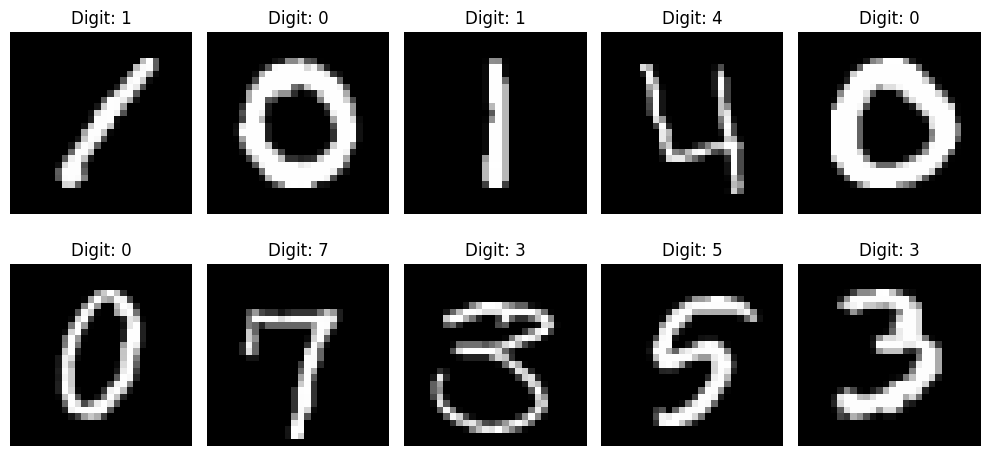

In [38]:
# ------------------------------------------------------------
# 6. Display sample handwritten digits
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

for i in range(10):

    image = X.iloc[i].values.reshape(28, 28)

    plt.subplot(2, 5, i + 1)

    plt.imshow(image, cmap="gray")

    plt.title("Digit: " + str(y.iloc[i]))

    plt.axis("off")

plt.tight_layout()
plt.show()

In [39]:
# ------------------------------------------------------------
# 7. Select a manageable number of samples
# ------------------------------------------------------------

# KNN can be slow with the complete 42000 samples.
# Therefore, we use 12000 samples.

MAX_SAMPLES = 12000

X_sample, _, y_sample, _ = train_test_split(
    X,
    y,
    train_size=MAX_SAMPLES,
    random_state=42,
    stratify=y
)

print("Selected samples:", X_sample.shape[0])

Selected samples: 12000


In [40]:
# ------------------------------------------------------------
# 8. Split the data into training and testing sets
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_sample,
    y_sample,
    test_size=0.20,
    random_state=42,
    stratify=y_sample
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 9600
Testing samples: 2400


In [41]:
# ------------------------------------------------------------
# 9. Normalize pixel values
# ------------------------------------------------------------

# Pixel values are between 0 and 255.
# Convert them to values between 0 and 1.

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Pixel values normalized successfully.")

Pixel values normalized successfully.


In [42]:
# ------------------------------------------------------------
# 10. Create the KNN classifier
# ------------------------------------------------------------

knn = KNeighborsClassifier(
    n_neighbors=3,
    metric="euclidean",
    n_jobs=-1
)

print("KNN classifier created.")

KNN classifier created.


In [43]:
# ------------------------------------------------------------
# 11. Train the KNN model
# ------------------------------------------------------------

knn.fit(X_train, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


In [44]:
# ------------------------------------------------------------
# 12. Predict the test data
# ------------------------------------------------------------

y_pred = knn.predict(X_test)

print("Prediction completed.")

Prediction completed.


In [45]:
# ------------------------------------------------------------
# 13. Calculate accuracy
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("KNN Accuracy:", round(accuracy * 100, 2), "%")

KNN Accuracy: 94.75 %


In [46]:
# ------------------------------------------------------------
# 14. Classification report
# ------------------------------------------------------------

print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.99      0.97       236
           1       0.92      0.99      0.95       268
           2       0.99      0.95      0.97       239
           3       0.93      0.95      0.94       249
           4       0.93      0.93      0.93       233
           5       0.95      0.93      0.94       217
           6       0.99      0.97      0.98       236
           7       0.93      0.95      0.94       251
           8       1.00      0.88      0.93       232
           9       0.92      0.92      0.92       239

    accuracy                           0.95      2400
   macro avg       0.95      0.95      0.95      2400
weighted avg       0.95      0.95      0.95      2400



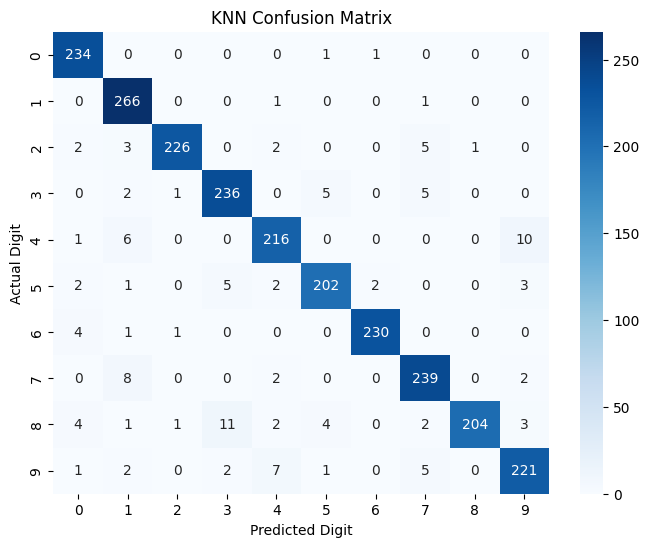

In [47]:
# ------------------------------------------------------------
# 15. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")

plt.title("KNN Confusion Matrix")

plt.show()

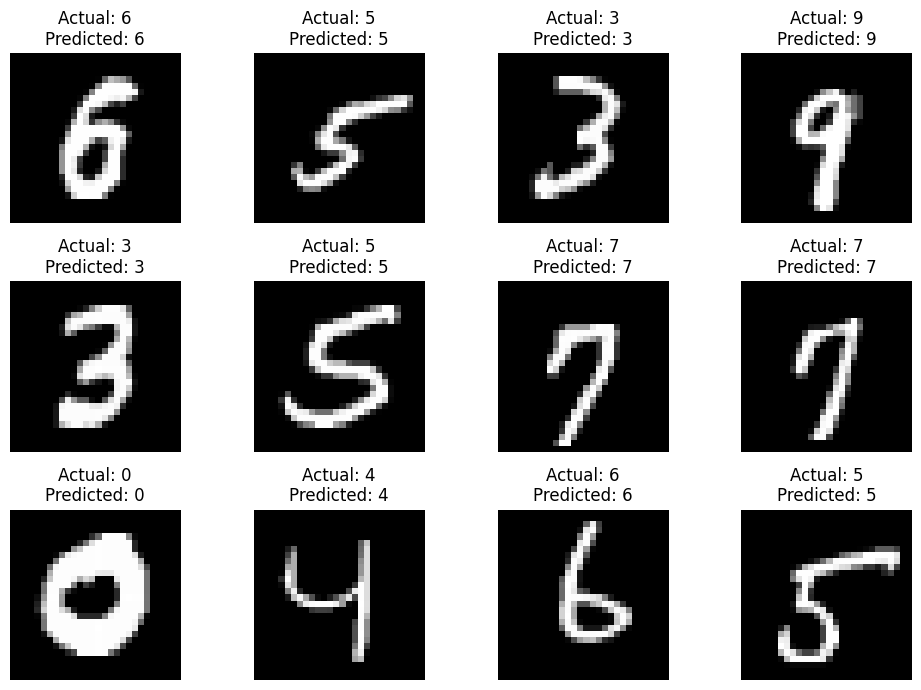

In [48]:
# ------------------------------------------------------------
# 16. Display actual and predicted digits
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

for i in range(12):

    image = X_test.iloc[i].values.reshape(28, 28)

    plt.subplot(3, 4, i + 1)

    plt.imshow(image, cmap="gray")

    plt.title(
        "Actual: " + str(y_test.iloc[i]) +
        "\nPredicted: " + str(y_pred[i])
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [49]:
# ------------------------------------------------------------
# 17. Upload a new handwritten digit
# ------------------------------------------------------------

print("Upload an image containing ONE handwritten digit.")

new_file = files.upload()

Upload an image containing ONE handwritten digit.


Saving Screenshot 2026-09-28 223750.png to Screenshot 2026-09-28 223750.png


In [50]:
# ------------------------------------------------------------
# 18. Read the new handwritten digit
# ------------------------------------------------------------

from PIL import Image

filename = list(new_file.keys())[0]

img = Image.open(filename).convert("L")

print("Image loaded:", filename)

print("Original image size:", img.size)

Image loaded: Screenshot 2026-09-28 223750.png
Original image size: (318, 292)


In [51]:
# ------------------------------------------------------------
# 19. Resize the image to 28 x 28
# ------------------------------------------------------------

img = img.resize((28, 28))

img_array = np.array(img)

print("New image size:", img_array.shape)

New image size: (28, 28)


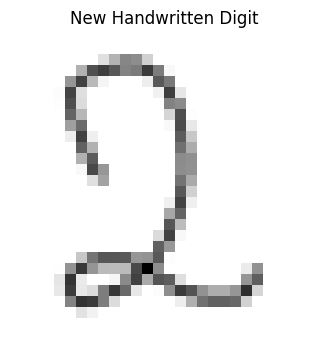

In [52]:
# ------------------------------------------------------------
# 20. Display the new handwritten digit
# ------------------------------------------------------------

plt.figure(figsize=(4, 4))

plt.imshow(img_array, cmap="gray")

plt.title("New Handwritten Digit")

plt.axis("off")

plt.show()

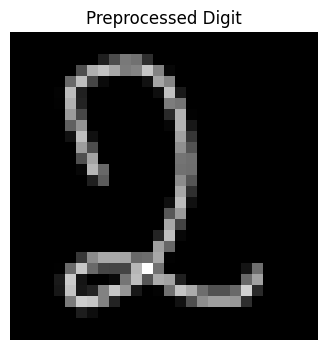

In [53]:
# ------------------------------------------------------------
# 21. Convert image to MNIST-like format
# ------------------------------------------------------------

# MNIST uses a dark background and bright digit.
# If the uploaded image has a white background,
# invert the image.

if img_array.mean() > 127:
    img_array = 255 - img_array

plt.figure(figsize=(4, 4))

plt.imshow(img_array, cmap="gray")

plt.title("Preprocessed Digit")

plt.axis("off")

plt.show()

In [54]:
# ------------------------------------------------------------
# 22. Convert image into 784 features
# ------------------------------------------------------------

new_digit = img_array.reshape(1, 784)

# Normalize pixel values
new_digit = new_digit.astype("float32") / 255.0

print("New digit shape:", new_digit.shape)

New digit shape: (1, 784)


In [55]:
# ------------------------------------------------------------
# 23. Predict the new handwritten digit
# ------------------------------------------------------------

new_prediction = knn.predict(new_digit)

print("--------------------------------------")
print("Predicted Handwritten Digit:",
      new_prediction[0])
print("--------------------------------------")

--------------------------------------
Predicted Handwritten Digit: 1
--------------------------------------


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [56]:
# ------------------------------------------------------------
# 24. Find the nearest handwritten samples
# ------------------------------------------------------------

distances, indices = knn.kneighbors(new_digit)

print("Nearest Neighbors:\n")

for i in range(3):

    index = indices[0][i]

    print(
        "Neighbor", i + 1,
        ": Digit =", y_train.iloc[index],
        ", Euclidean Distance =",
        round(distances[0][i], 4)
    )

Nearest Neighbors:

Neighbor 1 : Digit = 1 , Euclidean Distance = 5.6107
Neighbor 2 : Digit = 1 , Euclidean Distance = 5.6794
Neighbor 3 : Digit = 1 , Euclidean Distance = 5.8647


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


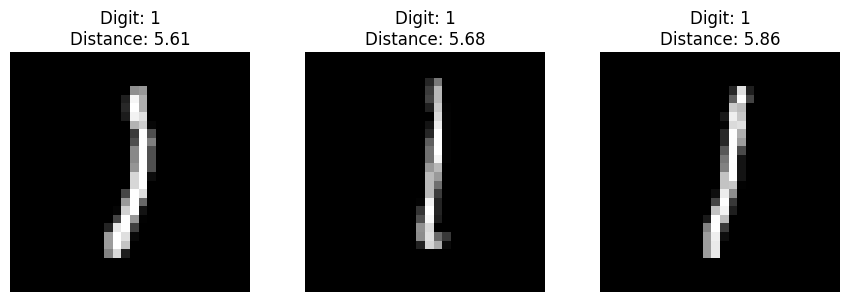

In [57]:
# ------------------------------------------------------------
# 25. Display nearest handwritten samples
# ------------------------------------------------------------

plt.figure(figsize=(9, 3))

for i in range(3):

    index = indices[0][i]

    image = X_train.iloc[index].values.reshape(28, 28)

    plt.subplot(1, 3, i + 1)

    plt.imshow(image, cmap="gray")

    plt.title(
        "Digit: " + str(y_train.iloc[index]) +
        "\nDistance: " +
        str(round(distances[0][i], 2))
    )

    plt.axis("off")

plt.tight_layout()
plt.show()